## Diagnostics & results


1. Compressor (stage-1) training curves
2. NLE (stage-2) training curves
3. Final evaluation (stage 4): SBC, corner plots, metrics table

Run this **on `tycho`** (via the VS Code tunnel) so it can see your scratch data. Edit the **Configuration** cell, then *Run All*.

> To make figures appear in the published Jupyter Book, run this notebook on the
> cluster and **save it with its outputs** before committing (see `notebooks/README.md`).

### Setup

Run everything from the repo root so `tools/…` and `eval.py` resolve, wherever Jupyter was launched.

In [1]:
import os, glob, subprocess
from pathlib import Path
from IPython.display import Image, display

REPO = subprocess.check_output(["git", "rev-parse", "--show-toplevel"]).decode().strip()
os.chdir(REPO)
OUT = Path("notebooks/_figs")
OUT.mkdir(parents=True, exist_ok=True)
print("working dir:", REPO)

working dir: /obs/ddehiwalage-don/21cm/sbi_project


### Configuration 

Point these at the run you want to inspect. `ARM_NLE` is the arm's stage-2 output
directory, i.e. `<scratch_root>/<arm_name>/nle` from that arm's config.

In [2]:
CONFIG = "configs_seeds/noise/arm_cnn_vmim_jitter_n1.yaml"  # the arm's config YAML (in-repo)
ARM_NLE = "/gscratch/ddehiwalage-don/sbi_master/cnn_vmim_/n1_jitter/seed_s0/nle"  # <-- edit: arm's stage-2 output dir
LABEL = "VMIM n1"  # legend label
FAMILY = "nsf"  # density family trained in stage 2 (gmm | maf | nsf)
SCOPE = "std"  # 'std' (standardized t) or 'raw'

### 1. Compressor training

Calls `tools/plot_training_compressor.py` and shows the figure inline.

wrote notebooks/_figs/compressor.pdf
wrote notebooks/_figs/compressor.png

best RF-R2 (per parameter):
  arm                   VMIM n1
  vmim                    0.951

final RF-R2 (per parameter):
  arm                   VMIM n1
  vmim                    0.929

RF-R2 at best-probe checkpoint (the one exported):
  arm                   VMIM n1
  vmim                    0.951

final sigma(theta_p|t)  [prior 0.289]:
  arm                   VMIM n1
  vmim                    0.014

wrote notebooks/_figs/compressor.tex  (RF-R2 at the exported checkpoint, \input{}-ready)


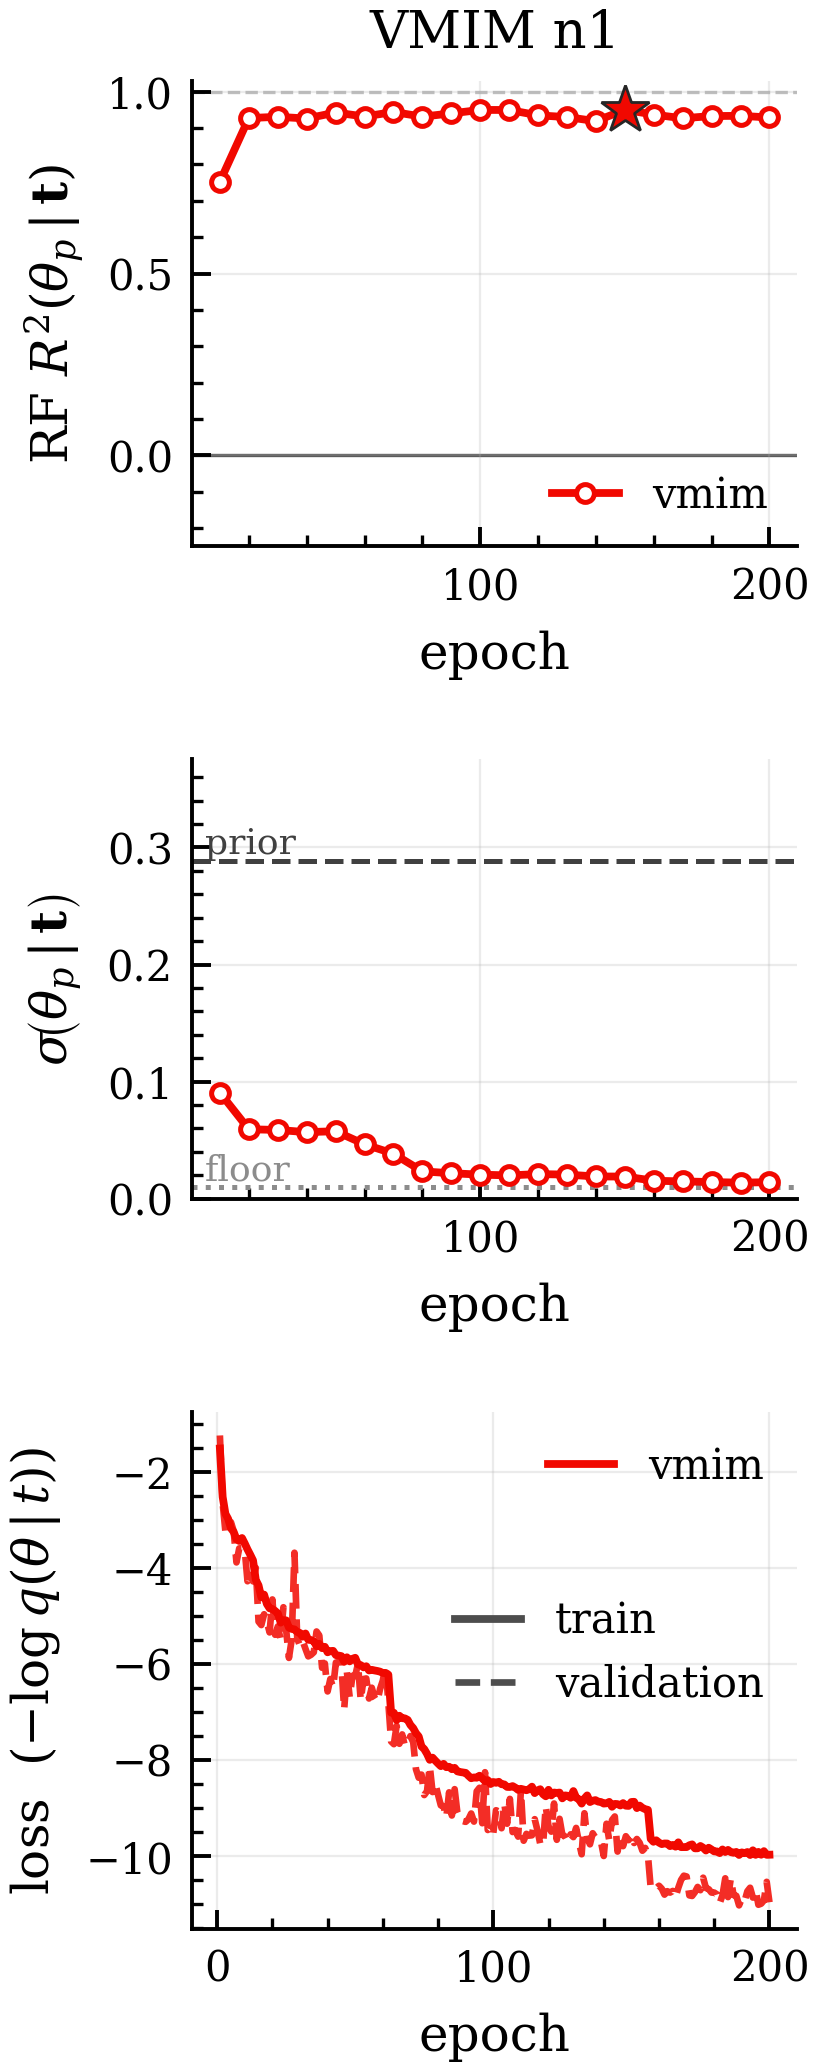

In [3]:
fig = OUT / "compressor.pdf"
!python tools/plot_training_compressor.py "vmim={ARM_NLE}" --names "{LABEL}" --out "{fig}" --png
png = fig.with_suffix(".png")
display(Image(str(png))) if png.exists() else print("No PNG produced — check the ARM_NLE path.")

## 2. NLE training
Calls `tools/plot_training_nle.py` on the config(s).

[arm_cnn_vmim_jitter_n1] discovered seeds=[0, 1, 2, 3, 4]  with loss data=[0, 1, 2, 3, 4]

[SUCCESS] wrote notebooks/_figs/nle_training.png


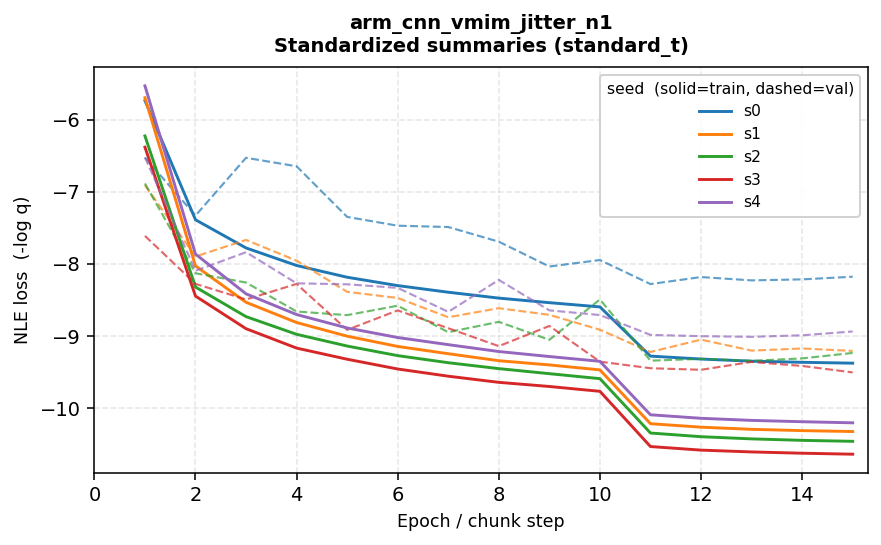

In [4]:
fig = OUT / "nle_training.png"
!python tools/plot_training_nle.py "{CONFIG}" --out "{fig}"
display(Image(str(fig))) if fig.exists() else print("No figure — check CONFIG / stage-2 outputs.")

## 3. Final evaluation (stage 4)
Runs `eval.py`, shows the **metrics table** inline, and previews each generated
PDF figure (SBC, corner). PDF preview uses poppler's `pdftoppm`; if it isn't
installed it simply lists the figure paths instead.

arms:
   VMIM n1                      <- cnn_vmim_/n1_jitter/seed_s0[standard_t_nsf]  (/gscratch/ddehiwalage-don/sbi_master/cnn_vmim_/n1_jitter/seed_s0/chains/standard_t_nsf)
shared sims across arms: 908
[mode] filtered dlogp10
[table] wrote notebooks/_figs/eval/metrics.csv  (filtered dlogp10)
[table] wrote notebooks/_figs/eval/metrics.tex

=== GV (median sqrt|Sigma_4x4|) / sigma (median IQR) / chi^2-to-flat ===
  VMIM n1                    N= 908 GV=1.511e-09 sigma=[0.0051, 0.0117, 0.0264, 0.0086] chi2=[0.037, 0.043, 0.038, 0.029]
[sbc] wrote notebooks/_figs/eval/sbc_filtered_dlogp10.pdf
[corner] shared sims: 908
[corner] median-GV sim (ref 'VMIM n1'): 878
[corner] wrote notebooks/_figs/eval/corner_sim878.pdf

done -> notebooks/_figs/eval/  (metrics.csv, metrics.tex, metrics.json, sbc_filtered_dlogp10.pdf, corner_sim878.pdf)


,,,,,,,,,,# mode: filtered dlogp10
arm,n_used,GV_4x4,sigma_0,sigma_1,sigma_2,sigma_3,calib_0,calib_1,calib_2,calib_3
cnn_vmim_/n1_jitter/seed_s0[standard_t_nsf],908,1.510564e-09,5.098976e-03,1.169283e-02,2.636653e-02,8.557951e-03,0.0370,0.0434,0.0382,0.0295


corner_sim878.pdf


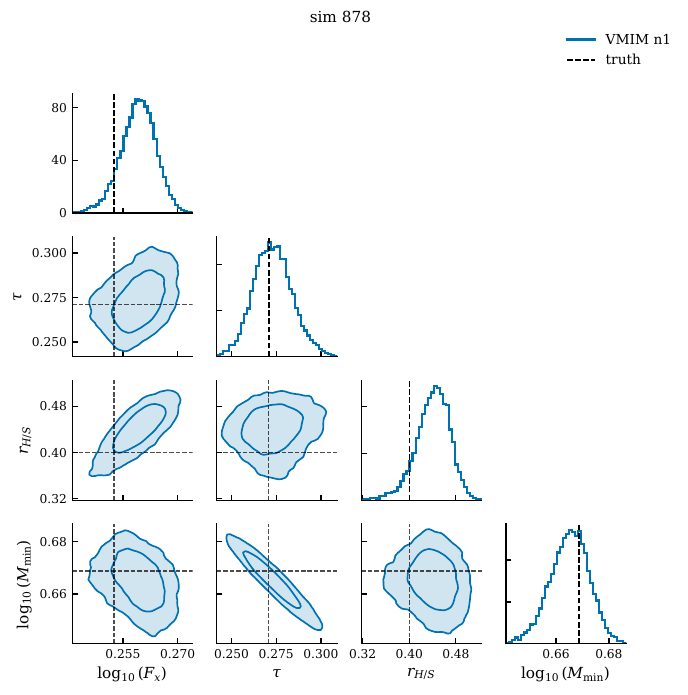

sbc_filtered_dlogp10.pdf


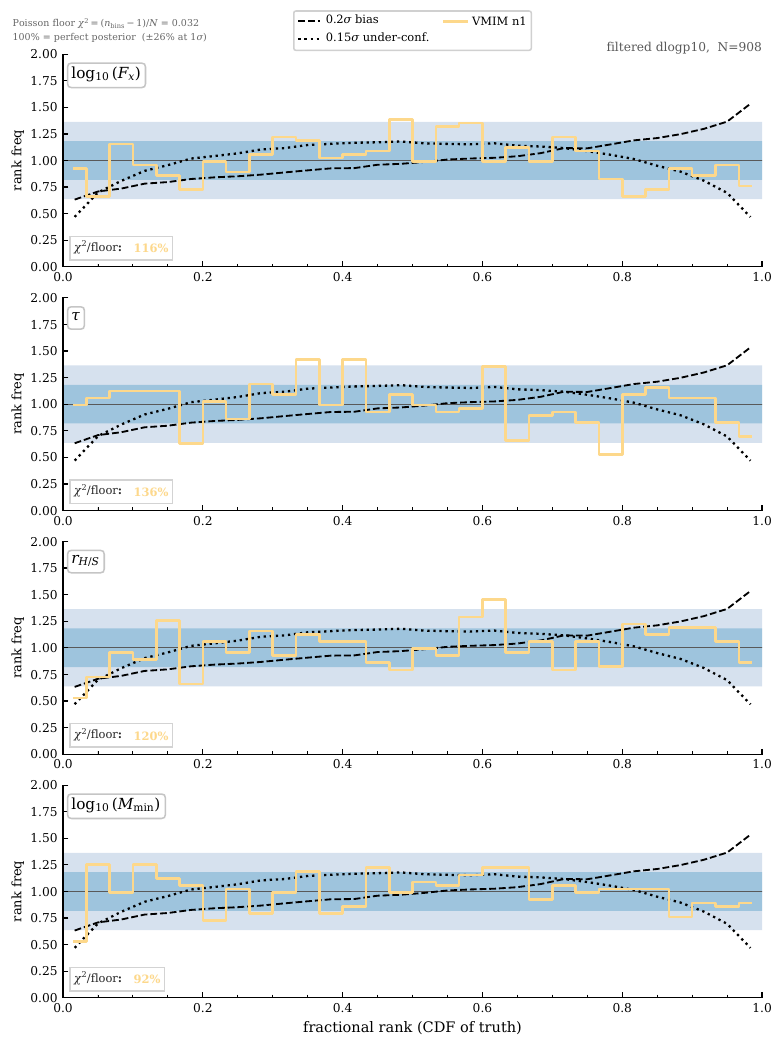

In [5]:
evdir = OUT / "eval"
!python eval.py --item "{CONFIG}|{FAMILY}|{SCOPE}|{LABEL}" --out "{evdir}"

# metrics table
try:
    import pandas as pd

    mcsv = evdir / "metrics.csv"
    if mcsv.exists():
        display(pd.read_csv(mcsv))
except Exception as e:
    print("metrics table skipped:", e)

# preview PDF figures (SBC, corner, ...)
for p in sorted(glob.glob(str(evdir / "*.pdf"))):
    prev = p[:-4] + "_preview"
    rc = os.system(f'pdftoppm -png -r 110 -singlefile "{p}" "{prev}" 2>/dev/null')
    if rc == 0 and os.path.exists(prev + ".png"):
        print(os.path.basename(p))
        display(Image(prev + ".png"))
    else:
        print("figure:", p)

---
*Generated figures live under `notebooks/_figs/` (git-ignored). To publish them in
the Jupyter Book, keep this notebook's saved outputs when you commit it.*